# Spot Price – Autoregressive Model

This notebook trains an autoregressive (AR) model on 15-minute spot prices
from the Energinet imbalance dataset.  The model uses its own past values
plus **sin/cos time-of-day features** (in Danish local time) to generate
price scenarios for the next delivery day.

**Setup:**
- Information cut-off at **11:00 UTC** → the model bridges 13 hours (52 quarter-hours) to midnight, then forecasts the full 24-hour delivery day (96 steps).
- Train on data up to **end of January 2026**; test on **February–March 2026**.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.scenarios.spot_price.ar_model import ARModel

## 1. Data Loading

Load the 15-minute spot prices from the Energinet imbalance dataset and split into
training (up to end of January 2026) and testing (February–March 2026) sets.

Total:   37196 obs  |  2025-03-04 12:00:00 → 2026-03-26 22:45:00
Train:   32016 obs  |  2025-03-04 12:00:00 → 2026-01-31 23:45:00
Test:     5180 obs  |  2026-02-01 00:00:00 → 2026-03-26 22:45:00


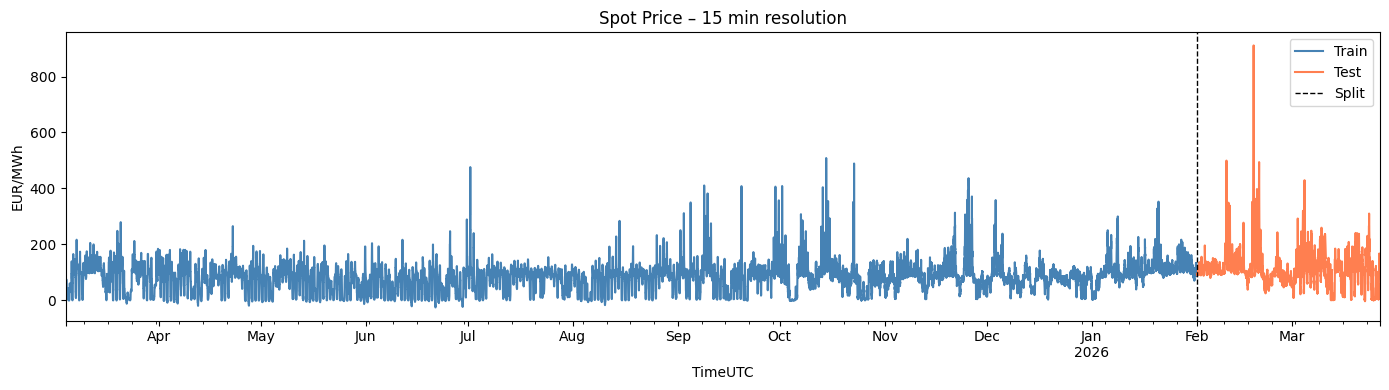

In [9]:
df = pd.read_csv("../data_samples/energinet_imbalance_prices_2024-2026.csv")
df["TimeUTC"] = pd.to_datetime(df["TimeUTC"])

prices = df.set_index("TimeUTC")["SpotPriceEUR"].dropna()

# Train / test split
train = prices[prices.index < "2026-02-01"]
test = prices[prices.index >= "2026-02-01"]

print(f"Total:  {len(prices):>6} obs  |  {prices.index[0]} → {prices.index[-1]}")
print(f"Train:  {len(train):>6} obs  |  {train.index[0]} → {train.index[-1]}")
print(f"Test:   {len(test):>6} obs  |  {test.index[0]} → {test.index[-1]}")

fig, ax = plt.subplots(figsize=(14, 4))
train.plot(ax=ax, label="Train", color="steelblue")
test.plot(ax=ax, label="Test", color="coral")
ax.axvline(pd.Timestamp("2026-02-01"), color="k", ls="--", lw=1, label="Split")
ax.set_ylabel("EUR/MWh")
ax.set_title("Spot Price – 15 min resolution")
ax.legend()
plt.tight_layout()

## 2. Model Fitting

Fit the AR model on the **training set only** (data before February 2026).
The default lags in 15-min steps are `[1, 2, 3, 4, 96, 192, 672]`, capturing:
- Short-term dynamics (15 min – 1 hour)
- Daily seasonality (96 steps = 24 h)
- Two-day pattern (192 steps = 48 h)
- Weekly seasonality (672 steps = 168 h)

Additionally, **sin/cos time-of-day** features are included (Danish time) to help
the model capture the daily price profile shape.

In [10]:
model = ARModel()
model.fit(train.values, train.index)

print(f"AR lags:         {model.ar_lags}")
print(f"AR coefficients: {dict(zip(model.ar_lags, np.round(model.ar_coefficients, 5)))}")
print(f"Time-of-day:     sin={model.time_coefficients[0]:.4f}, cos={model.time_coefficients[1]:.4f}")
print(f"Intercept:       {model.intercept:.4f}")
print(f"Residual std:    {model.residual_std:.4f} EUR/MWh")

AR lags:         [1, 2, 3, 4, 96, 192, 672]
AR coefficients: {1: np.float64(0.86947), 2: np.float64(0.04471), 3: np.float64(-0.00713), 4: np.float64(0.02833), 96: np.float64(0.03683), 192: np.float64(0.00655), 672: np.float64(0.02563)}
Time-of-day:     sin=-0.9628, cos=-0.5085
Intercept:       -0.3314
Residual std:    12.0435 EUR/MWh


## 3. Save Model

Persist the fitted model so it can be loaded via `SpotPriceGenerator(model="ar")`.

In [11]:
import os
os.makedirs("../trained_models/spot_price", exist_ok=True)
model.save("../trained_models/spot_price/ar.npz")
print("Model saved to trained_models/spot_price/ar.npz")

Model saved to trained_models/spot_price/ar.npz


## 4. Out-of-Sample Backtest (Feb – Mar 2026)

For each day in the test period, we simulate the operational setting:
1. Take all 15-min prices known up to **10:45 UTC** of that day (the 11:00 cut-off).
2. Generate 200 scenario paths for the **next delivery day** (00:00 – 23:45 UTC).
3. Compare the scenario fan against the actual realised prices.

In [12]:
# Build list of delivery days in the test set
test_days = pd.date_range(
    start=test.index[0].normalize(),
    end=test.index[-1].normalize(),
    freq="D",
)
# Keep only days where we have a full 96-step delivery window
test_days = [d for d in test_days if (d + pd.Timedelta("23h45min")) in prices.index]

max_lag = max(model.ar_lags)
n_scenarios = 200
results = []

for day in test_days:
    # Cut-off: 10:45 UTC on the day before delivery
    cutoff = day - pd.Timedelta("13h15min")
    known = prices[prices.index <= cutoff]
    if len(known) < max_lag:
        continue

    recent = known.values[-max_lag:]
    scenarios = model.generate(
        n_scenarios=n_scenarios,
        seed=None,
        recent_prices=recent,
        cutoff_utc=cutoff,
    )

    # Actual prices for the delivery day
    actual = prices[day : day + pd.Timedelta("23h45min")].values
    if len(actual) != 96:
        continue

    results.append({
        "day": day,
        "scenarios": scenarios,
        "actual": actual,
    })

print(f"Backtested {len(results)} delivery days")

Backtested 53 delivery days


### Backtest Metrics

Compute MAE (mean scenario vs actual) and empirical coverage of the 90% prediction interval across all test days.

In [13]:
maes = []
coverages = []

for r in results:
    mean_scen = r["scenarios"].mean(axis=0)
    maes.append(np.mean(np.abs(mean_scen - r["actual"])))

    lo = np.percentile(r["scenarios"], 5, axis=0)
    hi = np.percentile(r["scenarios"], 95, axis=0)
    coverages.append(np.mean((r["actual"] >= lo) & (r["actual"] <= hi)))

print(f"Mean MAE across test days:  {np.mean(maes):.2f} EUR/MWh")
print(f"Median MAE:                 {np.median(maes):.2f} EUR/MWh")
print(f"Mean 90% coverage:          {np.mean(coverages)*100:.1f}%")
print(f"Median 90% coverage:        {np.median(coverages)*100:.1f}%")

Mean MAE across test days:  41.84 EUR/MWh
Median MAE:                 34.61 EUR/MWh
Mean 90% coverage:          71.5%
Median 90% coverage:        77.1%


### Sample Days

Fan charts for a few selected test days showing scenarios vs actual prices.

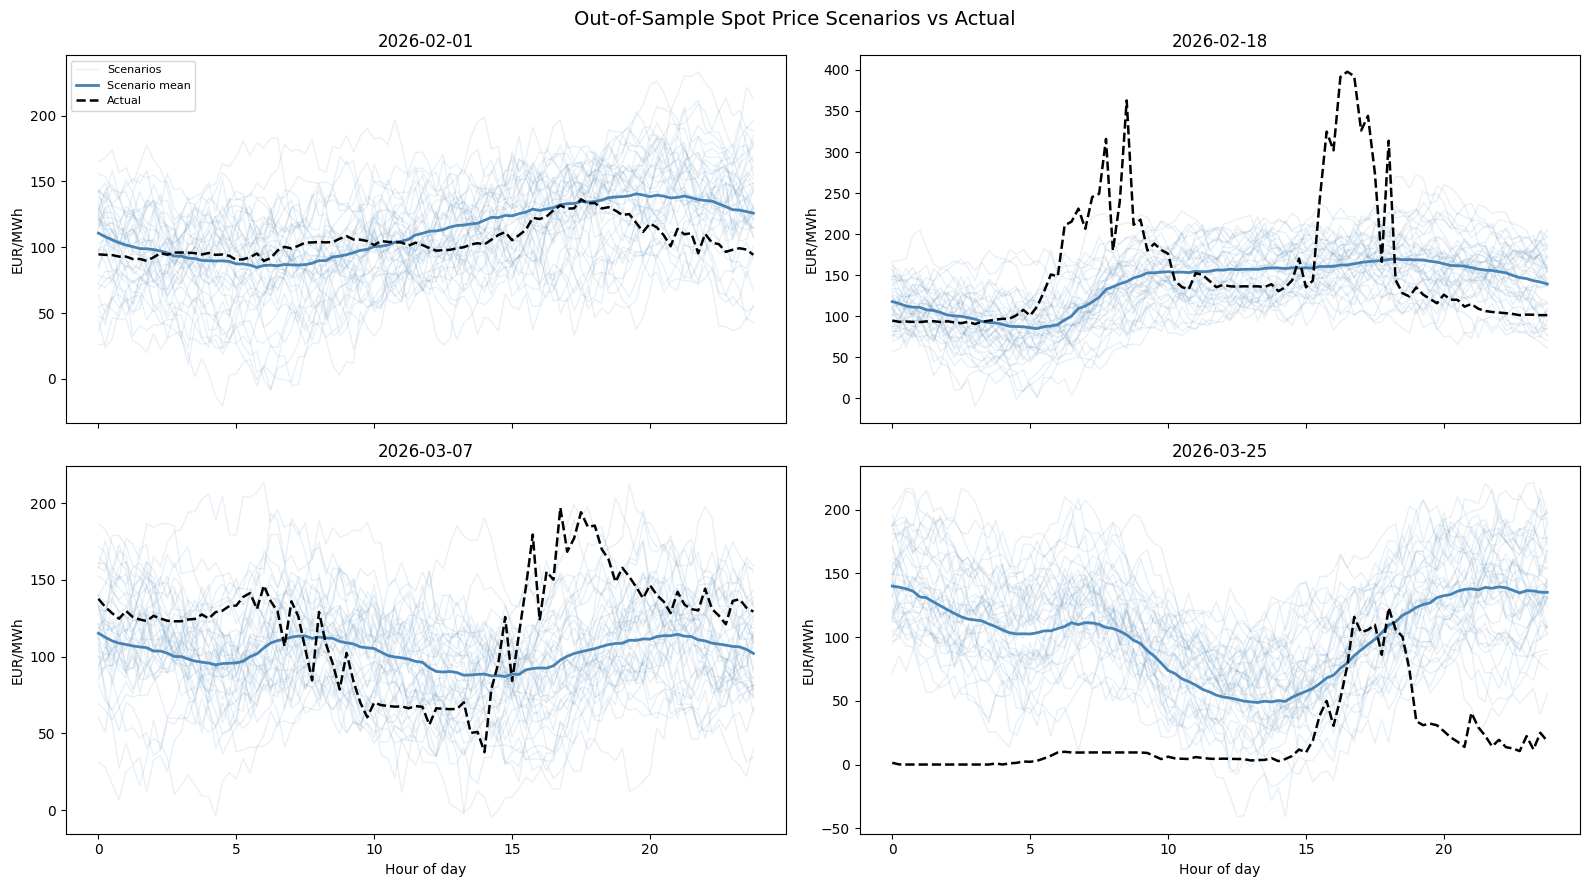

In [14]:
# Plot fan charts for 4 evenly-spaced test days
sample_idx = np.linspace(0, len(results) - 1, 4, dtype=int)
hours = np.arange(96) * 0.25

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
for ax, idx in zip(axes.flat, sample_idx):
    r = results[idx]
    scen = r["scenarios"]

    # Plot a subset of scenario paths to keep the chart readable
    n_plot = min(40, scen.shape[0])
    plot_idx = np.linspace(0, scen.shape[0] - 1, n_plot, dtype=int)

    for i, j in enumerate(plot_idx):
        ax.plot(
            hours,
            scen[j],
            color="steelblue",
            alpha=0.12,
            lw=1,
            label="Scenarios" if i == 0 else None,
        )

    ax.plot(hours, scen.mean(axis=0), color="steelblue", lw=2, label="Scenario mean")
    ax.plot(hours, r["actual"], color="k", lw=1.8, ls="--", label="Actual")
    ax.set_title(r["day"].strftime("%Y-%m-%d"))
    ax.set_ylabel("EUR/MWh")

axes[1, 0].set_xlabel("Hour of day")
axes[1, 1].set_xlabel("Hour of day")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Out-of-Sample Spot Price Scenarios vs Actual", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)